# Meridional Heat Transport

## CMIP6 variables 

This recipe calculates the model's meridional heat transport (MHT) using two methods based on distinct MOM5 diagnostics. The methods and the caveats associated with them are listed below:

### Method 1: Using `hfbasin` diagnostics

This CMIP6 variable has the following [info](https://github.com/PCMDI/cmip6-cmor-tables/blob/087fe45d21c082e28723e0f930e4266abe91b853/Tables/CMIP6_Omon.json#L1835):
```json
"standard_name": "northward_ocean_heat_transport", 
"units": "W", 
"cell_methods": "longitude: sum (comment: basin sum [along zig-zag grid path]) depth: sum time: mean", 
"cell_measures": "", 
"long_name": "Northward Ocean Heat Transport", 
"comment": "Contains contributions from all physical processes affecting the northward heat transport, including resolved advection, parameterized advection, lateral diffusion, etc. Diagnosed here as a function of latitude and basin.   Use Celsius for temperature scale.", 
"dimensions": "latitude basin time", 
``` 

### Method 2: Using surface and frazil heat fluxes (`hfds` and `hfsifrazil2d`)

This is an alternative method that approximates the meridional heat transport from surface heat fluxes. Note that this method relies on a steady state assumption. We use two diagnostics: `net_sfc_heating` (net surface heat flux) and `frazil_3d_int_z` which is the heat flux due to frazil formation at higher latitudes.
  
The recipe calculates the total (all basins) MHT, and it also includes comparisons to a few observational products. Basin-specific MHT can be calculated by defining relevant masks.

In [ ]:
from dask.distributed import Client

from esmvalcore.dataset import Dataset
from esmvalcore.preprocessor import (
    climate_statistics,
    axis_statistics,
    convert_units,
    zonal_statistics,
    regrid,
    histogram
)
import iris
import numpy as np

import iris.quickplot as qplt
import matplotlib.pyplot as plt


Start dask cluster.

In [3]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 2
Total threads: 2,Total memory: 9.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42309,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46875,Total threads: 1
Dashboard: /proxy/36203/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:34225,


## Method 1: Using online diagnostics

In [4]:
var = Dataset( # northward_ocean_heat_transport
    short_name='hfbasin', mip='Omon', project='CMIP6',
    activity='OMIP',  dataset='ACCESS-OM2',
    ensemble='r1i1p1f1', grid='gn',
    exp='omip2', timerange='0300/0305',
)

var.files

[LocalFile('/g/data/fs38/publications/CMIP6/OMIP/CSIRO-COSIMA/ACCESS-OM2/omip2/r1i1p1f1/Omon/hfbasin/gn/v20210616/hfbasin_Omon_ACCESS-OM2_omip2_r1i1p1f1_gn_024501-030512.nc')]

This CMIP variable has longitude summed, (see cell methods) and has 3 regions: 'atlantic_arctic_ocean', 'indian_pacific_ocean', 'global_ocean' so we select global_ocean.

We use climate statistics to get the mean over the full period and convert the dataset from Watts (W) to PetaWatts (PW).

In [65]:
cube = var.load()
cube = convert_units(var.load(), 'PetaWatts')
cube = climate_statistics(cube, period='full', operator='mean')

print(cube.summary(shorten=True), '\nregion coord:', cube.coord('region').points)
# cube[2].coords() #'global_ocean'
globalocean_hf_cube = cube.extract(iris.Constraint(region='global_ocean'))


northward_ocean_heat_transport / (PetaWatts) (-- : 3; latitude: 300) 
region coord: ['atlantic_arctic_ocean' 'indian_pacific_ocean' 'global_ocean']


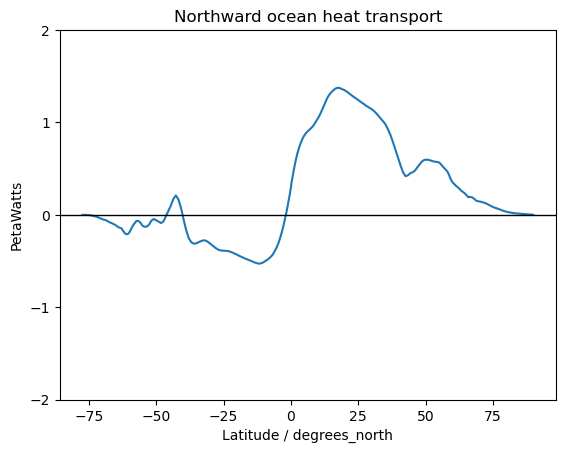

In [66]:
qplt.plot(globalocean_hf_cube)
plt.ylabel(cube.units)
plt.yticks(np.arange(-2,2.5,1))
plt.axhline(y=0, color='black', linewidth=1)
plt.show()

## Method 2: Using surface and frazil heat fluxes 

First, we load the surface heat flux and grid metrics:

In [67]:
#should be same dataset as above for comparison
hfds = Dataset(
    short_name='hfds', mip='Omon', project='CMIP6',
    activity='CMIP',  dataset='ACCESS-CM2',
    ensemble='*', grid='gn',
    exp='1pctCO2', timerange='1090/1095', #1pctCO2 
)
# hfds.files

#should be same dataset as above
hfrazil = Dataset(
    short_name='hfsifrazil', mip='Omon', project='CMIP6',
    activity='CMIP',  dataset='ACCESS-CM2',
    ensemble='r1i1p1f1', grid='gn',
    exp='1pctCO2', timerange='1090/1095',
)
# list(hfrazil.from_files())
print(hfrazil.files)

[LocalFile('/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/1pctCO2/r1i1p1f1/Omon/hfsifrazil/gn/v20191109/hfsifrazil_Omon_ACCESS-CM2_1pctCO2_r1i1p1f1_gn_095001-109912.nc'), LocalFile('/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/1pctCO2/r1i1p1f1/Omon/hfsifrazil/gn/v20191109/hfsifrazil_Omon_ACCESS-CM2_1pctCO2_r1i1p1f1_gn_109001-109912.nc')]


`hfrazil.load()` Dataset load fails because `olevel: does not exist`

This variable should be [_hfsifrazil2d_](https://github.com/PCMDI/cmip6-cmor-tables/blob/087fe45d21c082e28723e0f930e4266abe91b853/Tables/CMIP6_Omon.json#L2123) instead of _hfsifrazil_

We can load cube from file to bypass the CMOR checks then subset by the time period we are using.

In [69]:
from esmvalcore.preprocessor import extract_time

cubefz = iris.load_cube(hfrazil.files[0])
cubefz = extract_time(cubefz, start_year=1090, start_month=1, start_day=1, end_year=1095, end_month=12, end_day=31) 
print(cubefz.summary(shorten=True))
print('mean, max, min:', cubefz.data.mean(), cubefz.data.max(), cubefz.data.min(), cubefz.units)

heat_flux_into_sea_water_due_to_freezing_of_frazil_ice / (W m-2) (time: 72; cell index along second dimension: 300; cell index along first dimension: 360)
mean, max, min: 0.023306996849712915 106.17159 -54.64465 W m-2


#### supplementary datasets
There is an error with adding the supplementary with the dataset, around the facets it is using to create the dataset, for better control can add dataset as a list. (though not required in this calculation)
Example:
```python
hfds.add_supplementary(short_name='areacello', mip='Ofx')
# hfds.supplementaries[0].load() # error with loading - timerange..
Dataset(**hfds.supplementaries[0].minimal_facets).load()
hfds.supplementaries = [Dataset(**hfds.supplementaries[0].minimal_facets)]
```

Add the heat fluxes and take the `time` mean.

Now calculate Meridional Heat Flux (MHF). This is done by calculating the total heat flux as the heat flux times the area, and then integrating in latitude space such that for each latitude:

$$
\mathrm{MHF}(y) = \int_{y_{0}}^{y} (\mathrm{SHFLUX} \times \mathrm{AREA}) \, \mathrm{d}y
$$

- Multiply by area cube, 
- regrid for lat/lon dimensions, sum longitude,
- cumulative sum along latitude,
- add correction

In [49]:
# 'grid': 'native atmosphere N96 grid (144x192 latxlon)'
print((144/180), (192/360)) # target lon by lat

0.8 0.5333333333333333


In [78]:
cube = hfds.load()
# hfds includes frazil already so does not need this..
# cube.data = cube.data + cubefz.data

# time mean
cube = climate_statistics(cube, period='full', operator='mean')

# load area cube
area = Dataset(**hfds.copy(short_name='areacello', mip='Ofx').minimal_facets).load()

cube = cube * area
# resolution to match datafor summing
cube = regrid(cube, '0.5x0.8', 'linear') #linear?
cube = zonal_statistics(cube, 'sum') #sum longitude
print(cube.summary(shorten=True))

 hfds: attribute positive not present
loaded from file 


unknown / (W)                       (latitude: 225)


In [79]:
# integral
mht_cumsum_data = np.cumsum(cube.data)
mht_transport = cube.copy(data=mht_cumsum_data)
mht_transport = convert_units(mht_transport, 'PetaWatts')

# correction
first_valid = np.ma.compressed(mht_transport.data)[0]
last_valid  = np.ma.compressed(mht_transport.data)[-1]

offset = (first_valid - last_valid) / 2
mht_transport.data = mht_transport.data + offset
mht_transport.long_name = 'Meridional_heat_transport'

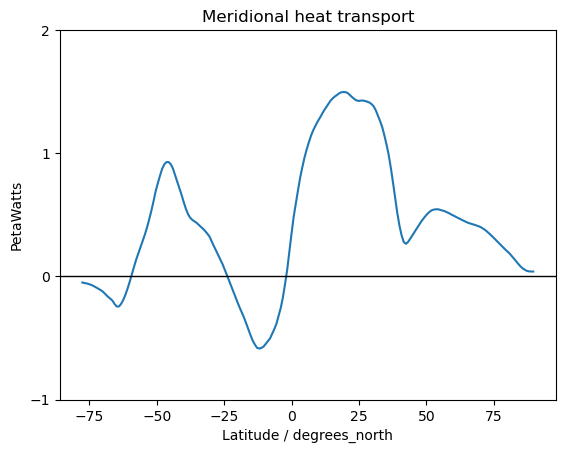

In [80]:
qplt.plot(mht_transport)
plt.ylabel(mht_transport.units)
plt.yticks(np.arange(-1,2.1,1))
plt.axhline(y=0, color='black', linewidth=1)
plt.show()

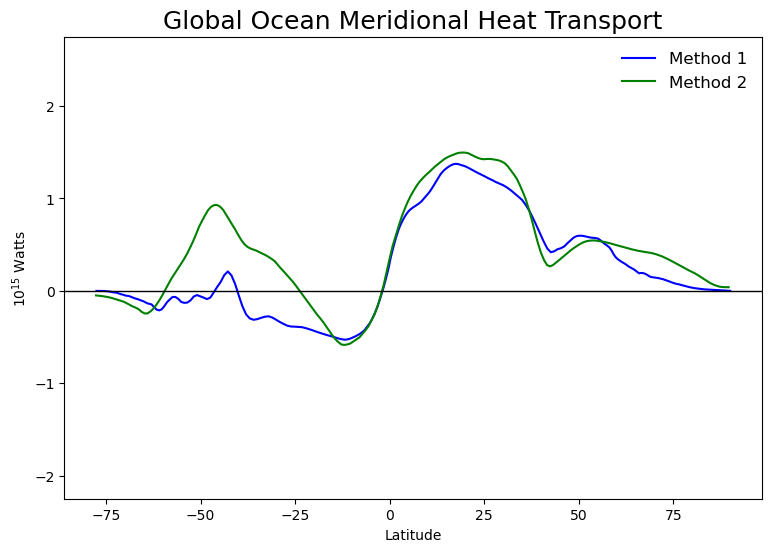

In [81]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot()

qplt.plot(globalocean_hf_cube, color = 'blue', label = 'Method 1')
qplt.plot(mht_transport, color = 'green', label = 'Method 2')


# add legend
plt.legend(frameon=False, fontsize=12)
plt.axhline(y=0, linewidth=1, color='black')

# limits along the y axis
plt.ylim(-2.25, 2.75)

# add titles and labels
plt.title('Global Ocean Meridional Heat Transport', fontsize=18)
plt.xlabel('Latitude')
plt.ylabel('$10^{15}$ Watts');

## Comparison between model output and observations

The following section compares the model's heat transport to observations. These observations are derived using various methods, in particular using surface flux observations a la method 2 (which assumes a steady state).

### Read ERBE Period Ocean and Atmospheric Heat Transport

This data comes (annoyingly) in a text file. The cell below opens and saves latitudes and heat transport into two separate lists: 

In [74]:
# Path to the file containing observations
filename = '/g/data3/ik11/from_hh5_tmp/cosima/observations/original/MHT/obs_vq_am_estimates.txt'

# Create empty variables to store our observations
erbe_MHT = []
erbe_lat = []

# Open data and save it to empty variables above
with open(filename) as f:
    #Open each line from rows 1 to 96
    for line in f.readlines()[1:96]:
        #Separating each line to extract data
        line = line.strip()
        sline = line.split()
        #Extracting latitude and MHT and saving to empty variables
        erbe_lat.append(float(sline[0]))
        erbe_MHT.append(float(sline[3]))

### Read NCEP and ECMWF Oceanic and Atmospheric Transport Products

These datasets are available at https://climatedataguide.ucar.edu/climate-data. We use a climatological mean of surface fluxes or vertically integrated total energy divergence for oceanic and atmospheric transports respectively for the period between February 1985 - April 1989.

This also comes as a text file and again, we will save it into lists. There is also an estimate of the observational error:

In [75]:
#Path to the file containing observations
filename = '/g/data/ik11/observations/ANNUAL_TRANSPORTS_1985_1989.ascii'

#Creating empty variables to store our observations
ncep_g_mht = []
ecwmf_g_mht = []
ncep_g_err = []
ecwmf_g_err = []
ncep_a_mht = []
ecwmf_a_mht = []
ncep_a_err = []
ecwmf_a_err = []
ncep_p_mht = []
ecwmf_p_mht = []
ncep_p_err = []
ecwmf_p_err = []
ncep_i_mht = []
ecwmf_i_mht = []
ncep_i_err = []
ecwmf_i_err = []
ncep_ip_mht = []
ecwmf_ip_mht = []
ncep_ip_err = []
ecwmf_ip_err = []
o_lat = []

#Opening data and saving it to empty variables above
with open(filename) as f:
#Open each line in file (ignoring the first row)
    for line in f.readlines()[1:]:
        #Separating each line to extract data
        line = line.strip()
        sline = line.split()
        #Extracting values and saving to correct variable defined above
        o_lat.append(float(sline[0]) * 0.01)         # T42 latitudes (north to south)
        ncep_g_mht.append(float(sline[4]) * 0.01)    # Residual Ocean Transport - NCEP
        ecwmf_g_mht.append(float(sline[5]) * 0.01)   # Residual Ocean Transport - ECWMF
        ncep_a_mht.append(float(sline[7]) * 0.01)    # Atlantic Ocean Basin Transport - NCEP
        ncep_p_mht.append(float(sline[8]) * 0.01)    # Pacific Ocean Basin Transport - NCEP
        ncep_i_mht.append(float(sline[9]) * 0.01)    # Indian Ocean Basin Transport - NCEP
        ncep_g_err.append(float(sline[10]) * 0.01)   # Error Bars for NCEP Total Transports
        ncep_a_err.append(float(sline[11]) * 0.01)   # Error Bars for NCEP Atlantic Transports 
        ncep_p_err.append(float(sline[12]) * 0.01)   # Error Bars for NCEP Pacific Transports 
        ncep_i_err.append(float(sline[13]) * 0.01)   # Error Bars for NCEP Indian Transports 
        ecwmf_a_mht.append(float(sline[15]) * 0.01)  # Atlantic Ocean Basin Transport - ECWMF
        ecwmf_p_mht.append(float(sline[16]) * 0.01)  # Pacific Ocean Basin Transport - ECWMF
        ecwmf_i_mht.append(float(sline[17]) * 0.01)  # Indian Ocean Basin Transport - ECWMF
        ecwmf_g_err.append(float(sline[18]) * 0.01)  # Error Bars for ECWMF Total Transports
        ecwmf_a_err.append(float(sline[19]) * 0.01)  # Error Bars for NCEP Atlantic Transports
        ecwmf_p_err.append(float(sline[20]) * 0.01)  # Error Bars for NCEP Pacific Transports
        ecwmf_i_err.append(float(sline[21]) * 0.01)  # Error Bars for NCEP Indian Transports

#Calculating MHT
ncep_ip_mht  = [a+b for a, b in zip(ncep_p_mht,ncep_i_mht)]
ecwmf_ip_mht = [a+b for a, b in zip(ecwmf_p_mht,ecwmf_i_mht)]
ncep_ip_err  = [max(a, b) for a, b in zip(ncep_p_err, ncep_i_err)]
ecwmf_ip_err = [max(a, b) for a, b in zip(ecwmf_p_err, ecwmf_i_err)]

## Plotting model outputs against observations

We plot the global meridional heat transport as calculated from model outputs (blue line) and observations.

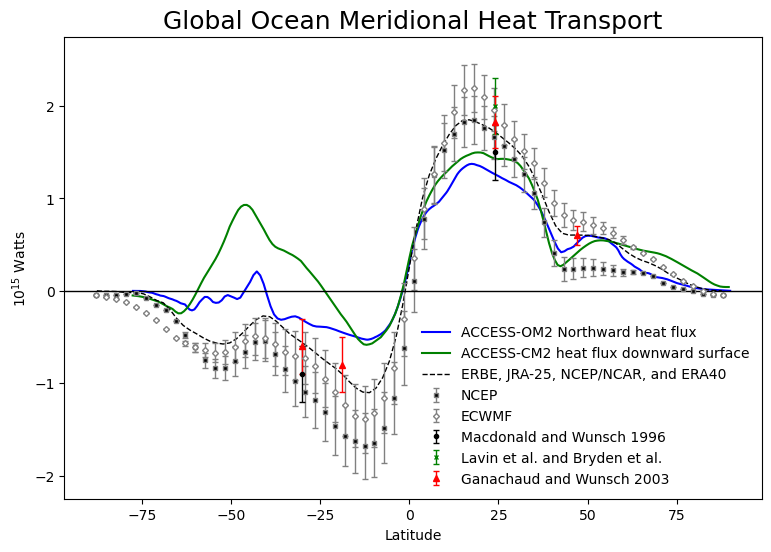

In [76]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(1, 1, 1)

#Plotting MHT from model outputs
qplt.plot(globalocean_hf_cube, color = 'blue', label = 'ACCESS-OM2 Northward heat flux')
qplt.plot(mht_transport, color = 'green', label = 'ACCESS-CM2 heat flux downward surface')

#Adding observations and error bars for observations
ax.plot(erbe_lat, erbe_MHT, 'k--', linewidth=1, label="ERBE, JRA-25, NCEP/NCAR, and ERA40")
plt.errorbar(o_lat[::-1], ncep_g_mht[::-1], yerr=ncep_g_err[::-1], c='gray', fmt='s', 
             markerfacecolor='k', markersize=3, capsize=2, linewidth=1, label="NCEP")
plt.errorbar(o_lat[::-1], ecwmf_g_mht[::-1], yerr=ecwmf_g_err[::-1], c='gray', fmt='D', 
             markerfacecolor='white', markersize=3, capsize=2, linewidth=1, label="ECWMF")
plt.errorbar( 24,  1.5, yerr=0.3, fmt='o', c='black', markersize=3, capsize=2, linewidth=1,
             label="Macdonald and Wunsch 1996")
plt.errorbar(-30, -0.9, yerr=0.3, fmt='o', c='black', markersize=3, capsize=2, linewidth=1)
plt.errorbar( 24,  2.0, yerr=0.3, fmt='x', c='green', markersize=3, capsize=2, linewidth=1,
             label="Lavin et al. and Bryden et al.")
plt.errorbar( 24,  1.83, yerr=0.28, fmt='^', c='red', markersize=4, capsize=2, linewidth=1,
             label="Ganachaud and Wunsch 2003")
plt.errorbar(-30, -0.6, yerr=0.3, fmt='^', c='red', markersize=4, capsize=2, linewidth=1)
plt.errorbar(-19, -0.8, yerr=0.3, fmt='^', c='red', markersize=4, capsize=2, linewidth=1)
plt.errorbar( 47,  0.6, yerr=0.1, fmt='^', c='red', markersize=4, capsize=2, linewidth=1)

# add legend
plt.legend(frameon=False, fontsize=10)
plt.axhline(y=0, linewidth=1, color='black')

# limits along the y axis
plt.ylim(-2.25, 2.75)

# add titles and labels
plt.title('Global Ocean Meridional Heat Transport', fontsize=18)
plt.xlabel('Latitude')
plt.ylabel('$10^{15}$ Watts');

In [77]:
client.close()